IMPORTING LIBRARIES AND LOADING DATASET

In [ ]:
# Importing essential libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import textwrap
from matplotlib.ticker import PercentFormatter, FuncFormatter

# Loading CSV file
df = pd.read_csv("dataset/user_events.csv")

DATA QUALITY CHECKS AND DATATYPE CONVERTING

In [ ]:
# Initial data checks
df.head()
df.info()
df.describe()

# Converting column data type from string to datetime in order to manipulate dates
df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
df["product_id"] = df["product_id"].astype(str)

In [ ]:
# Exploring data
df.event_id.duplicated().sum()
df.event_type.unique()
df.product_id.unique()
df.traffic_source.unique()

In [ ]:
# Filtering main dataframe to one with event dates not older than 1 month
df_last30days = df[df["event_date"] >= df["event_date"].max() - timedelta(days=30)]

In [ ]:
# Identifying anomaly data - users that 'skipped' page_view stage
users_stages_pivot_df = df_last30days.pivot_table(
    index="user_id", columns="event_type", aggfunc="size", fill_value=0
).sort_values(by="page_view")
users_without_page_view = users_stages_pivot_df.loc[
    users_stages_pivot_df["page_view"] == 0
].index
users_without_page_view

Index([5200], dtype='int64', name='user_id')

FUNNEL STAGES EVENT COUNT ANALYSIS

In [ ]:
# Building dataframe with event count numbers
event_count = {
    "Views": df_last30days.loc[
        df_last30days["event_type"] == "page_view", "user_id"
    ].nunique(),
    "Cart": df_last30days.loc[
        df_last30days["event_type"] == "add_to_cart", "user_id"
    ].nunique(),
    "Checkout": df_last30days.loc[
        df_last30days["event_type"] == "checkout_start", "user_id"
    ].nunique(),
    "Payment": df_last30days.loc[
        df_last30days["event_type"] == "payment_info", "user_id"
    ].nunique(),
    "Purchase": df_last30days.loc[
        df_last30days["event_type"] == "purchase", "user_id"
    ].nunique(),
}

event_df = pd.DataFrame([event_count])
event_df

,Views,Cart,Checkout,Payment,Purchase
0,4268,1332,951,768,708


CONVERSION RATES ANALYSIS

In [ ]:
# Making dataframe with conversion rate values
conversion_rates = {
    "Overall Conversion Rate": round(
        event_count["Purchase"] / event_count["Views"] * 100, 1
    ),
    "Views to Cart Rate": round(event_count["Cart"] / event_count["Views"] * 100, 1),
    "Cart to Checkout Rate": round(
        event_count["Checkout"] / event_count["Cart"] * 100, 1
    ),
    "Checkout To Payment Rate": round(
        event_count["Payment"] / event_count["Checkout"] * 100, 1
    ),
    "Payment to Purchase Rate": round(
        event_count["Purchase"] / event_count["Payment"] * 100, 1
    ),
}
conversion_df = pd.DataFrame([conversion_rates])
conversion_df

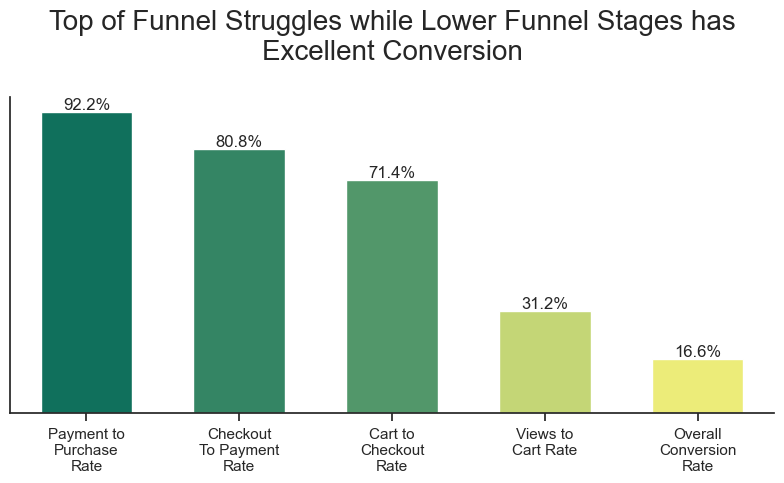

In [ ]:
# Plotting Conversion rates between different funnel stages
plt.figure(figsize=(8, 5))
sns.set_theme(style="ticks")
sns.barplot(
    x=conversion_df.columns,
    y=conversion_df.loc[0],
    hue=conversion_df.loc[0],
    palette="summer_r",
    width=0.6,
    legend=False,
)
sns.despine()
plt.title(
    "Top of Funnel Struggles while Lower Funnel Stages has Excellent Conversion",
    wrap=True,
    fontsize=20,
    pad=30,
)
plt.gca().invert_xaxis()
plt.xlabel("")
plt.ylabel("")
plt.yticks([])
for i, v in enumerate(conversion_df.loc[0]):
    plt.text(i, v + 1, f"{str(v)}%", ha="center")
ax = plt.gca()

# Wrap x-axis tick labels text
old_labels = [label.get_text() for label in ax.get_xticklabels()]
new_labels = [textwrap.fill(l, width=10) for l in old_labels]
ax.set_xticks(range(len(old_labels)))
ax.set_xticklabels(new_labels)

plt.tight_layout()
plt.show()

In [ ]:
# Building pivot table with conversion rates per marketing channel
columns_order = ["page_view", "add_to_cart", "purchase"]
key_purchase_funnel_events_df = df_last30days[
    df_last30days["event_type"].isin(columns_order)
]
funnel_channel_pivot_df = key_purchase_funnel_events_df.pivot_table(
    index="traffic_source", columns="event_type", aggfunc="size"
)
funnel_channel_pivot_df = funnel_channel_pivot_df.reindex(
    columns=columns_order
).sort_values("purchase", ascending=False)
funnel_channel_pivot_df.loc["total"] = funnel_channel_pivot_df.sum()
funnel_channel_pivot_df["page_view_pct"] = round(
    funnel_channel_pivot_df["page_view"]
    / funnel_channel_pivot_df.loc["total", "page_view"]
    * 100,
    1,
)
funnel_channel_pivot_df = funnel_channel_pivot_df.drop(index="total")
funnel_channel_pivot_df["view_to_cart_rate"] = round(
    funnel_channel_pivot_df["add_to_cart"] / funnel_channel_pivot_df["page_view"] * 100,
    1,
)
funnel_channel_pivot_df["view_to_purchase_rate"] = round(
    funnel_channel_pivot_df["purchase"] / funnel_channel_pivot_df["page_view"] * 100, 1
)
funnel_channel_pivot_df["cart_to_purchase_rate"] = round(
    funnel_channel_pivot_df["purchase"] / funnel_channel_pivot_df["add_to_cart"] * 100,
    1,
)
funnel_channel_pivot_df

25.0


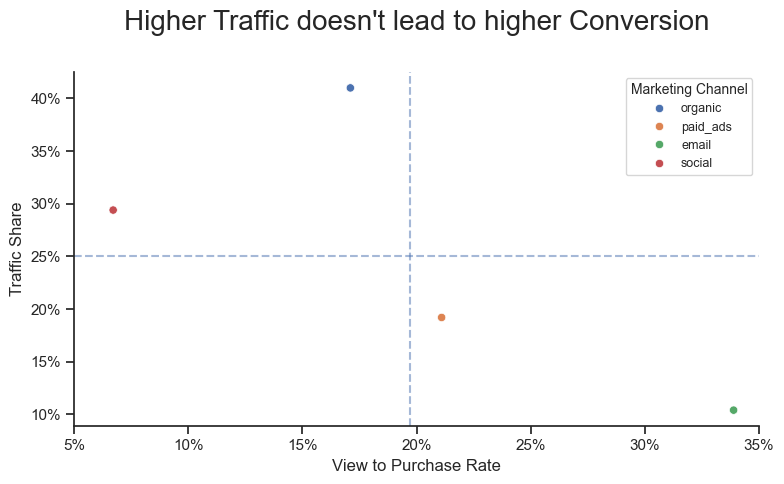

In [ ]:
# Building scatter plot to see the relation between traffic share and purchase rates
plt.figure(figsize=(8, 5))
sns.set_theme(style="ticks")
avg_traffic = funnel_channel_pivot_df["page_view_pct"].mean()
avg_conversion = funnel_channel_pivot_df["view_to_purchase_rate"].mean()
print(avg_traffic)
sns.scatterplot(
    data=funnel_channel_pivot_df,
    y="page_view_pct",
    x="view_to_purchase_rate",
    hue="traffic_source",
)
sns.despine()
plt.title("Higher Traffic doesn't lead to higher Conversion", fontsize=20, pad=30)
plt.xlabel("View to Purchase Rate")
plt.ylabel("Traffic Share")
plt.xlim(5, 35)
plt.legend(title="Marketing Channel", title_fontsize=10, fontsize=9)

plt.axhline(y=avg_traffic, linestyle="--", alpha=0.5)
plt.axvline(x=avg_conversion, linestyle="--", alpha=0.5)
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.tight_layout()

DROP-OFF ANALYSIS

In [ ]:
# Drop off rates pivot dataframe
funnel_steps = [
    "page_view",
    "add_to_cart",
    "checkout_start",
    "payment_info",
    "purchase",
]
channel_pivot_df = df_last30days.pivot_table(
    index="event_type", columns="traffic_source", aggfunc="size"
)
channel_pivot_df = channel_pivot_df.reindex(funnel_steps)
channel_pivot_df.loc["View to Cart Rate"] = 100 - round(
    channel_pivot_df.loc["add_to_cart"] / channel_pivot_df.loc["page_view"] * 100, 2
)
channel_pivot_df.loc["Cart to Checkout Rate"] = 100 - round(
    channel_pivot_df.loc["checkout_start"] / channel_pivot_df.loc["add_to_cart"] * 100,
    2,
)
channel_pivot_df.loc["Checkout to Payment Rate"] = 100 - round(
    channel_pivot_df.loc["payment_info"] / channel_pivot_df.loc["checkout_start"] * 100,
    2,
)
channel_pivot_df.loc["Payment to Purchase Rate"] = 100 - round(
    channel_pivot_df.loc["purchase"] / channel_pivot_df.loc["payment_info"] * 100, 2
)
channel_pivot_df = channel_pivot_df.drop(
    ["page_view", "add_to_cart", "checkout_start", "payment_info", "purchase"]
)
channel_pivot_df

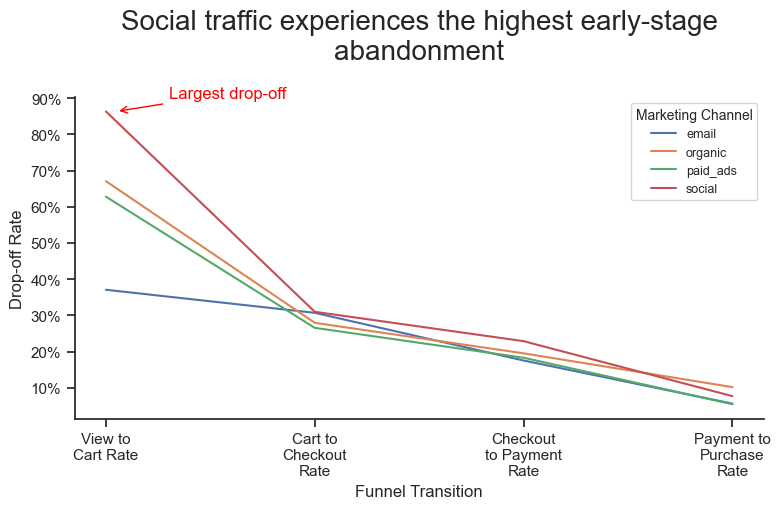

In [ ]:
# Building line plot to see what are the drop-off rates for every marketing channel through the funnel
plt.figure(figsize=(8, 5))
sns.set_theme(style="ticks")
sns.lineplot(data=channel_pivot_df.loc["View to Cart Rate":], dashes=False)
sns.despine()
plt.title(
    "Social traffic experiences the highest early-stage abandonment",
    fontsize=20,
    pad=30,
    wrap=True,
)
plt.xlabel("Funnel Transition")
plt.ylabel("Drop-off Rate")
plt.legend(title="Marketing Channel", title_fontsize=10, fontsize=9)
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
max_drop = channel_pivot_df.loc["View to Cart Rate"].max()
plt.annotate(
    "Largest drop-off",
    xy=(0.05, max_drop),
    xytext=(0.3, 90),
    color="red",
    arrowprops=dict(arrowstyle="->", color="red"),
)

old_labels = [label.get_text() for label in ax.get_xticklabels()]
new_labels = [textwrap.fill(l, width=10) for l in old_labels]
ax.set_xticks(range(len(old_labels)))
ax.set_xticklabels(new_labels)
plt.tight_layout()

REVENUE PER MARKETING CHANNEL

In [ ]:
# Calculating revenue and average customer value per marketing channel
revenue_per_source = df_last30days.groupby("traffic_source")["amount"].sum()
pivot_copy = funnel_channel_pivot_df[["page_view", "purchase"]].copy()
source_revenue_df = pivot_copy.merge(revenue_per_source, on="traffic_source")
columns_names = ["Total Visitors", "Total Customers", "Total Revenue"]
source_revenue_df.columns = columns_names
source_revenue_df["Average Customer Value"] = round(
    source_revenue_df["Total Revenue"] / source_revenue_df["Total Customers"], 2
)
source_revenue_df["Revenue Per Visitor"] = round(
    source_revenue_df["Total Revenue"] / source_revenue_df["Total Visitors"], 2
)
source_revenue_df

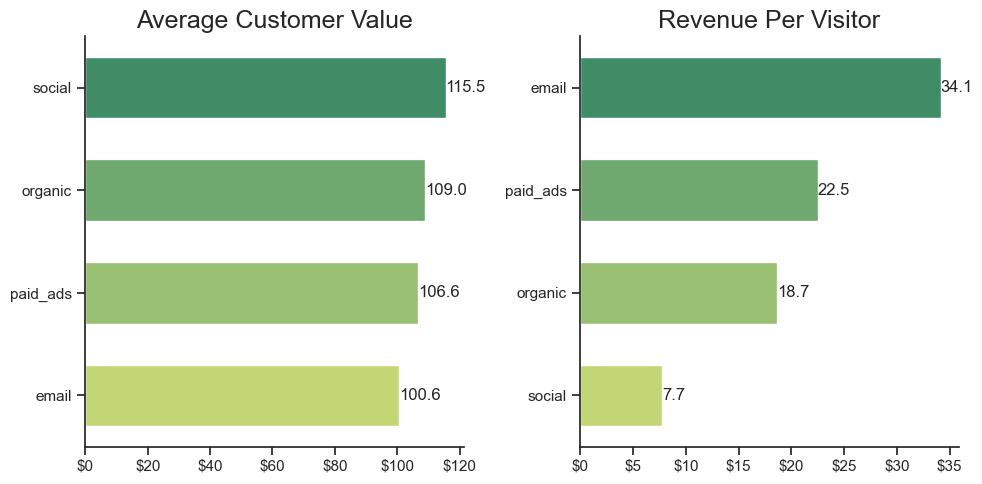

In [ ]:
# Marketing channel revenue analysis hbar plot
channel_revenue_df = source_revenue_df.loc[:, "Average Customer Value":].copy()
columns = ["Average Customer Value", "Revenue Per Visitor"]
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.set_theme(style="ticks")
for i, val in enumerate(columns):
    sorted_df = channel_revenue_df[[columns[i]]].sort_values(
        by=columns[i], ascending=False
    )
    sns.barplot(
        data=sorted_df,
        x=columns[i],
        y=sorted_df.index,
        hue=sorted_df.index,
        palette="summer",
        ax=ax[i],
        width=0.6,
    )
    ax[i].set_title(columns[i], fontsize=18)
    ax[i].set_ylabel("")
    ax[i].set_xlabel("")
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${x:.0f}"))
    for n, v in enumerate(sorted_df[columns[i]]):
        ax[i].text(v, n, f"{v:.1f}", va="center")
sns.despine()
fig.tight_layout()
plt.show()

PRODUCT REVENUE PERFORMANCE BY MARKETING CHANNEL

In [ ]:
product_channel_pivot_df = df_last30days.pivot_table(
    values="amount", index="traffic_source", columns="product_id", aggfunc="sum"
)
product_channel_pivot_df

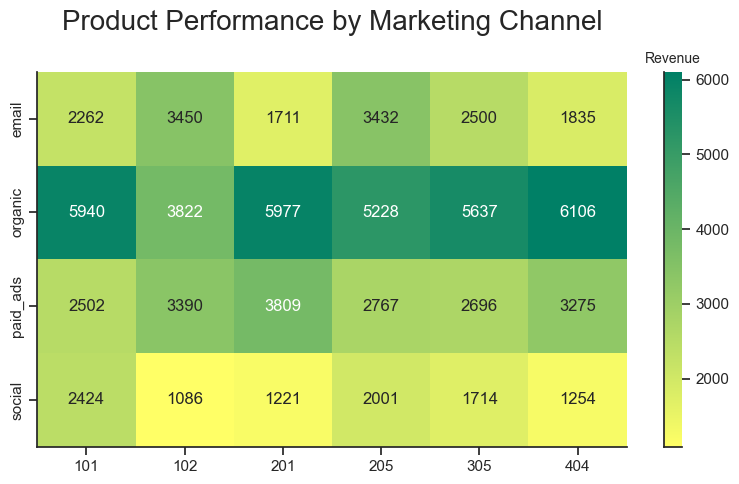

In [ ]:
# Building heatmap to see the monetary performance by every product
plt.figure(figsize=(8, 5))
sns.set_theme(style="ticks")
sns.heatmap(product_channel_pivot_df, annot=True, fmt=".0f", cmap="summer_r")
ax = plt.gca()
ax.collections[0].colorbar.ax.set_title("Revenue", fontsize=10)
sns.despine()
plt.title("Product Performance by Marketing Channel", fontsize=20, pad=30)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()

CONVERSION RATES AND TRAFFIC SHARE BY PRODUCT

In [ ]:
product_funnel_pivot_df = df_last30days.pivot_table(
    index="product_id", columns="event_type", aggfunc="size"
)
product_funnel_pivot_df = product_funnel_pivot_df.reindex(columns=funnel_steps)
product_funnel_pivot_df.loc["total"] = product_funnel_pivot_df.sum()
product_funnel_pivot_df["page_view_pct"] = round(
    product_funnel_pivot_df["page_view"]
    / product_funnel_pivot_df.loc["total", "page_view"]
    * 100,
    1,
)
product_funnel_pivot_df = product_funnel_pivot_df.drop(index="total")
product_funnel_pivot_df["view_to_purchase_rate"] = round(
    product_funnel_pivot_df["purchase"] / product_funnel_pivot_df["page_view"] * 100, 1
)
product_funnel_pivot_df = product_funnel_pivot_df.drop(
    columns=["page_view", "add_to_cart", "checkout_start", "payment_info", "purchase"]
)
product_funnel_pivot_df

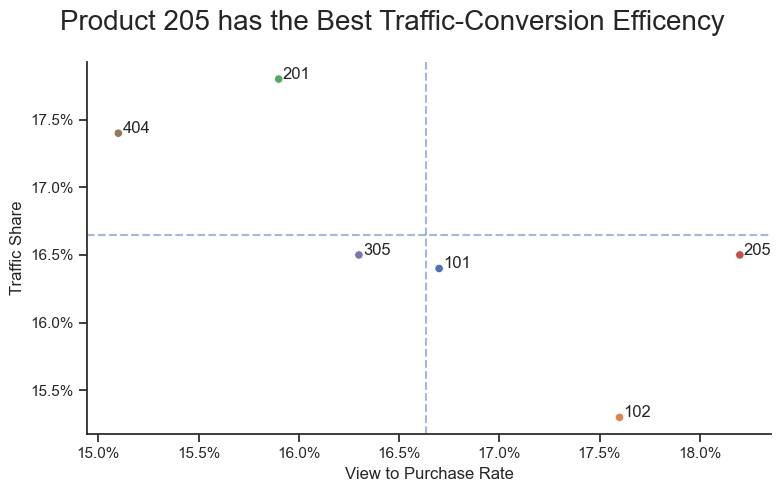

In [ ]:
# Building scatter plot to see the relation between traffic share and purchase rates
plt.figure(figsize=(8, 5))
sns.set_theme(style="ticks")
avg_traffic = product_funnel_pivot_df["page_view_pct"].mean()
avg_conversion = product_funnel_pivot_df["view_to_purchase_rate"].mean()
sns.scatterplot(
    data=product_funnel_pivot_df,
    y="page_view_pct",
    x="view_to_purchase_rate",
    hue="product_id",
    legend=False,
)
sns.despine()
plt.suptitle(
    "Product 205 has the Best Traffic-Conversion Efficency", fontsize=20, wrap=True
)
plt.xlabel("View to Purchase Rate")
plt.ylabel("Traffic Share")
plt.axhline(y=avg_traffic, linestyle="--", alpha=0.5)
plt.axvline(x=avg_conversion, linestyle="--", alpha=0.5)
for x, y, v in zip(
    product_funnel_pivot_df["view_to_purchase_rate"],
    product_funnel_pivot_df["page_view_pct"],
    product_funnel_pivot_df.index,
):
    plt.text(x + 0.02, y, v)

ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=1))
ax.yaxis.set_major_formatter(PercentFormatter(decimals=1))
plt.tight_layout()

DAILY AND WEEKLY VOLUME AND REVENUE ANALYSIS

In [ ]:
# Creating pivot dataframe with every day and hour posibility to see when purchases most often occur
import calendar

df_last30days["day_of_week"] = df_last30days["event_date"].dt.day_of_week
df_last30days["hours"] = df_last30days["event_date"].dt.hour
day_hour_pivot_df = df_last30days.pivot_table(
    values="amount", index="day_of_week", columns="hours", aggfunc="count"
).reset_index()
day_hour_pivot_df["weekday_name"] = day_hour_pivot_df["day_of_week"].apply(
    lambda x: calendar.day_name[x]
)
day_hour_pivot_df = day_hour_pivot_df.set_index("weekday_name").drop(
    columns="day_of_week"
)
day_hour_pivot_df

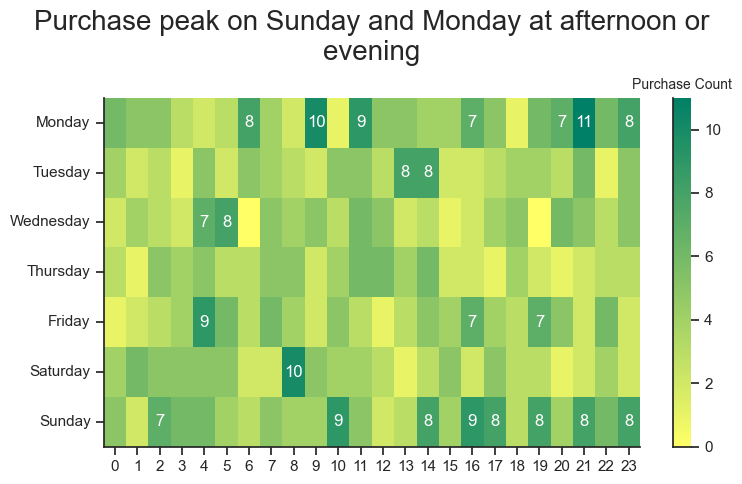

In [ ]:
# Building heatmap to see which days and hours are customers the most active
plt.figure(figsize=(8, 5))
sns.set_theme(style="ticks")
annot_text = day_hour_pivot_df.map(lambda x: f"{x}" if x > 6 else "")
sns.heatmap(day_hour_pivot_df, annot=annot_text, fmt="", cmap="summer_r")
ax = plt.gca()
ax.collections[0].colorbar.ax.set_title("Purchase Count", fontsize=10)
sns.despine()
plt.title(
    "Purchase peak on Sunday and Monday at afternoon or evening",
    fontsize=20,
    pad=30,
    wrap=True,
)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()